<a href="https://colab.research.google.com/github/Meghna0606/air-quality/blob/main/Copy_of_AIR_QUALITY.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1. UPLOADING DATASET AND COMBINING THE FILES

In [ ]:
from google.colab import files
import pandas as pd
import io

uploaded = files.upload()

import os
import zipfile

# If you have uploaded a ZIP file, extract it
for filename in uploaded.keys():
    if filename.endswith('.zip'):
        with zipfile.ZipFile(io.BytesIO(uploaded[filename]), 'r') as zip_ref:
            zip_ref.extractall("/content/data/")

folder_path = "/content/data/"

# Read and combine all CSV files in the folder
dfs = []
for file in os.listdir(folder_path):
    if file.endswith('.csv'):
        file_path = os.path.join(folder_path, file)
        df = pd.read_csv(file_path)

        # Combine year, month, day, hour into a timestamp
        df['timestamp'] = pd.to_datetime(df[['year', 'month', 'day', 'hour']])

        # Drop original date/time columns if you want
        df.drop(columns=['No', 'year', 'month', 'day', 'hour'], inplace=True)

        dfs.append(df)

# Combine all into one DataFrame
full_df = pd.concat(dfs, ignore_index=True)

# Sort by timestamp
full_df = full_df.sort_values('timestamp').reset_index(drop=True)

# Preview the result
print(full_df.head())


Saving archive (2).zip to archive (2).zip
   PM2.5  PM10   SO2   NO2     CO    O3  TEMP    PRES  DEWP  RAIN   wd  WSPM  \
0    4.0   4.0   3.0   NaN  200.0  82.0  -2.3  1020.8 -19.7   0.0    E   0.5   
1    5.0  14.0   4.0  12.0  200.0  85.0  -0.5  1024.5 -21.4   0.0  NNW   5.7   
2    4.0   4.0  14.0  20.0  300.0  69.0  -0.7  1023.0 -18.8   0.0  NNW   4.4   
3    3.0   6.0   3.0   8.0  300.0  44.0  -0.9  1025.8 -20.5   0.0   NW   9.3   
4    3.0   6.0  13.0   7.0  300.0  85.0  -2.3  1020.8 -19.7   0.0    E   0.5   

        station  timestamp  
0      Dingling 2013-03-01  
1  Nongzhanguan 2013-03-01  
2      Guanyuan 2013-03-01  
3        Shunyi 2013-03-01  
4     Changping 2013-03-01  


2.PREPROCESSING

- Convert the timestamp column to datetime and sort the data by station and timestamp.

- For each station, impute missing numeric values:

Use linear interpolation for gaps shorter than 8 hours.

For longer gaps (≥8 hours), fill missing values by averaging the same hour's values from the previous and next day.

- Drop features with more than 50% missing values.

- Map wind direction categorical values to degrees, then apply cyclical encoding using sine and cosine transformations; drop original wind direction columns.

- Extract the hour of day from timestamps and apply cyclical encoding (sine and cosine) to capture daily periodicity.

- Normalize numeric features (excluding timestamp, station, and cyclical features) using MinMaxScaler.

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler

# Cyclical encoding helper
def cyclical_encode(series, max_val):                 #e.g., hour of day, wind direction
    radians = 2 * np.pi * series / max_val
    return np.sin(radians), np.cos(radians)

# Imputation function for one station's data (assumes hourly data, sorted by timestamp)
def impute_missing_values(df, time_col='timestamp'):
    df = df.set_index(time_col)

    for col in df.columns:
        if col in ['station', 'wd']:  # Skip non-numeric or categorical columns except 'wd' which is handled separately
            continue

        is_missing = df[col].isna().to_numpy()
        if not is_missing.any():
            continue

        gaps = []
        start_idx = None
        for i in range(len(is_missing)):
            if is_missing[i] and start_idx is None:
                start_idx = i
            elif not is_missing[i] and start_idx is not None:
                gaps.append((start_idx, i-1))
                start_idx = None
        if start_idx is not None:
            gaps.append((start_idx, len(is_missing)-1))

        for start, end in gaps:
            gap_length = end - start + 1
            gap_hours = gap_length  # hourly data assumed

            if gap_hours < 8:
                # Linear interpolation for small gaps
                left_bound = max(start - 1, 0)
                right_bound = min(end + 2, len(df))

                interp_slice = df[col].iloc[left_bound:right_bound].interpolate(method='linear')

                expected_len = gap_length

                if start == 0:
                    interp_values = interp_slice.iloc[:expected_len].values
                elif end == len(df) - 1:
                    interp_values = interp_slice.iloc[-expected_len:].values
                else:
                    interp_values = interp_slice.iloc[1:-1].values

                idx_to_fill = df.index[start:end+1]

                if len(interp_values) != expected_len:
                    # fallback forward fill if mismatch
                    df.loc[idx_to_fill, col] = df[col].ffill().loc[idx_to_fill]
                    continue

                df.loc[idx_to_fill, col] = interp_values

            else:
                # For large gaps >= 8 hours, use average of same hour previous and next day
                for idx in range(start, end + 1):
                    current_time = df.index[idx]
                    prev_day = current_time - pd.Timedelta(days=1)
                    next_day = current_time + pd.Timedelta(days=1)
                    prev_val = df[col].get(prev_day, np.nan)
                    next_val = df[col].get(next_day, np.nan)
                    vals = [v for v in [prev_val, next_val] if not pd.isna(v)]
                    if vals:
                        df.loc[current_time, col] = np.mean(vals)
                    else:
                        # fallback linear interpolation for single point
                        df.loc[current_time, col] = df[col].interpolate(method='linear').loc[current_time]

    return df.reset_index()

# Main preprocessing function for the full dataset (multiple cities)
def preprocess_air_quality_data(full_df):

    # Convert timestamp to datetime and sort by City and timestamp
    full_df['timestamp'] = pd.to_datetime(full_df['timestamp'])
    full_df = full_df.sort_values(['station', 'timestamp']).reset_index(drop=True)

    # Impute missing values per station (city)
    imputed_dfs = []
    for station, group in full_df.groupby('station'):
        group_sorted = group.sort_values('timestamp').reset_index(drop=True)
        imputed_group = impute_missing_values(group_sorted, time_col='timestamp')
        imputed_dfs.append(imputed_group)
    full_df = pd.concat(imputed_dfs, ignore_index=True)

    # Remove features(columns) with >50% missing values
    missing_ratio = full_df.isna().mean()
    features_to_drop = missing_ratio[missing_ratio > 0.5].index
    full_df.drop(columns=features_to_drop, inplace=True)


    # 0° = 360° = North → It’s a circle.

    # Simply using degrees (0 to 360) confuses models (because 0 and 360 are close but numerically far).

    # Map wind direction 'wd' to degrees and cyclical encode (do this before model training)
    wind_mapping = {
                      'N': 0, 'NNE': 22.5, 'NE': 45, 'ENE': 67.5, 'E': 90, 'ESE': 112.5,
                      'SE': 135, 'SSE': 157.5, 'S': 180, 'SSW': 202.5, 'SW': 225, 'WSW': 247.5,
                      'W': 270, 'WNW': 292.5, 'NW': 315, 'NNW': 337.5
                                    }
    full_df['wind_deg'] = full_df['wd'].map(wind_mapping).fillna(0)
    full_df['wind_sin'], full_df['wind_cos'] = cyclical_encode(full_df['wind_deg'], 360)
    full_df.drop(columns=['wd', 'wind_deg'], inplace=True)


  # 23:00 → 0:00 → 1:00 = continuous, circular relationship.

  # Using sin/cos makes sure 23 and 0 are close numerically for the model.


    # Cyclical encode hour of day
    full_df['hour'] = full_df['timestamp'].dt.hour
    full_df['hour_sin'], full_df['hour_cos'] = cyclical_encode(full_df['hour'], 24)
    full_df.drop(columns=['hour'], inplace=True)

    #X_scaled= (X-X_min)/(X_max-X_min)

    # Normalize numeric columns excluding timestamp and station
    scaler = MinMaxScaler()
    exclude_cols = ['timestamp', 'station', 'hour_sin', 'hour_cos', 'wind_sin', 'wind_cos']
    numeric_cols = full_df.select_dtypes(include=[np.number]).columns.difference(exclude_cols)
    full_df[numeric_cols] = scaler.fit_transform(full_df[numeric_cols])

    return full_df


preprocessed_df = preprocess_air_quality_data(full_df)
print(preprocessed_df.head())


            timestamp     PM2.5      PM10       SO2       NO2        CO  \
0 2013-03-01 00:00:00  0.002006  0.002006  0.007433  0.020671  0.020202   
1 2013-03-01 01:00:00  0.006018  0.006018  0.007433  0.020671  0.020202   
2 2013-03-01 02:00:00  0.005015  0.005015  0.009434  0.031053  0.020202   
3 2013-03-01 03:00:00  0.004012  0.004012  0.021441  0.034514  0.020202   
4 2013-03-01 04:00:00  0.001003  0.001003  0.023442  0.037974  0.020202   

         O3      TEMP      PRES      DEWP  RAIN      WSPM       station  \
0  0.071710  0.312195  0.672185  0.339310   0.0  0.333333  Aotizhongxin   
1  0.071710  0.305691  0.675497  0.347586   0.0  0.356061  Aotizhongxin   
2  0.067974  0.305691  0.680464  0.347586   0.0  0.424242  Aotizhongxin   
3  0.067040  0.300813  0.697020  0.331034   0.0  0.234848  Aotizhongxin   
4  0.067040  0.291057  0.708609  0.329655   0.0  0.151515  Aotizhongxin   

   wind_sin  wind_cos  hour_sin  hour_cos  
0 -0.382683  0.923880  0.000000  1.000000  
1  0.00000

fills remaining missing values in the DataFrame using forward and backward fill methods and confirms no NaNs remain

In [ ]:

# Final NaN fill to catch any remaining missing values
preprocessed_df.fillna(method='ffill', inplace=True)              # Forward fill: If a value is missing (NaN), fill it using the previous row's value.
preprocessed_df.fillna(method='bfill', inplace=True)              # Backward fill: If a value is still missing, fill it using the next row's value.

# Verify no NaNs remain
assert not preprocessed_df.isna().any().any(), "NaNs still remain after final fill"


<ipython-input-3-289914848fbe>:2: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  preprocessed_df.fillna(method='ffill', inplace=True)
<ipython-input-3-289914848fbe>:3: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  preprocessed_df.fillna(method='bfill', inplace=True)


3.FEATURE SELECTION

using decision tree classifier finding the features which play importance for each pollutant using standard cpcb threshold values in their standard averaging windows

In [ ]:
# CPCB (Central Pollution Control Board, India)
# CPCB Threshold values for pollutants (µg/m³ or mg/m³ converted to µg/m³)

thresholds_cpcb = {                              # safe limit values
    'O3': 100,       # µg/m³
    'PM2.5': 60,     # µg/m³
    'PM10': 100,     # µg/m³
    'NO2': 80,       # µg/m³
    'SO2': 80,       # µg/m³
    'CO': 2000       # µg/m³ (2 mg/m³ = 2000 µg/m³)
}

# Averaging periods for pollutants

#  Pollutants are assessed over specific time periods to calculate exposure averages.
averaging_windows = {
    'O3': 8,
    'PM2.5': 24,
    'PM10': 24,
    'NO2': 1,
    'SO2': 24,
    'CO': 8
}

# Calculate min/max of original pollutant values before normalization
original_df = full_df.copy()  # raw, unscaled data you used for preprocessing
original_df['timestamp'] = pd.to_datetime(original_df['timestamp'])

pollutant_min_max = {}
for pollutant in thresholds_cpcb.keys():
    pollutant_min_max[pollutant] = {
        'min': original_df[pollutant].min(),
        'max': original_df[pollutant].max()
    }

# Convert CPCB thresholds to normalized scale (0-1) for feature selection
normalized_thresholds = {}
for pollutant, cpcb_value in thresholds_cpcb.items():
    min_val = pollutant_min_max[pollutant]['min']
    max_val = pollutant_min_max[pollutant]['max']

    normalized_thresholds[pollutant] = (cpcb_value - min_val) / (max_val - min_val)

print("Normalized thresholds (0-1):")
print(normalized_thresholds)

Normalized thresholds (0-1):
{'O3': 0.09318931946986968, 'PM2.5': 0.058174523570712136, 'PM10': 0.09829488465396188, 'NO2': 0.27328976532450205, 'SO2': 0.15951991777703423, 'CO': 0.1919191919191919}


Purpose:    Identify which features in your dataset are most important for predicting pollution exceedance events for each pollutant.

Method Used:   Decision Tree Classifier → feature importances → top features visualization.


Processing pollutant: O3

Processing pollutant: PM2.5

Processing pollutant: PM10

Processing pollutant: NO2

Processing pollutant: SO2

Processing pollutant: CO


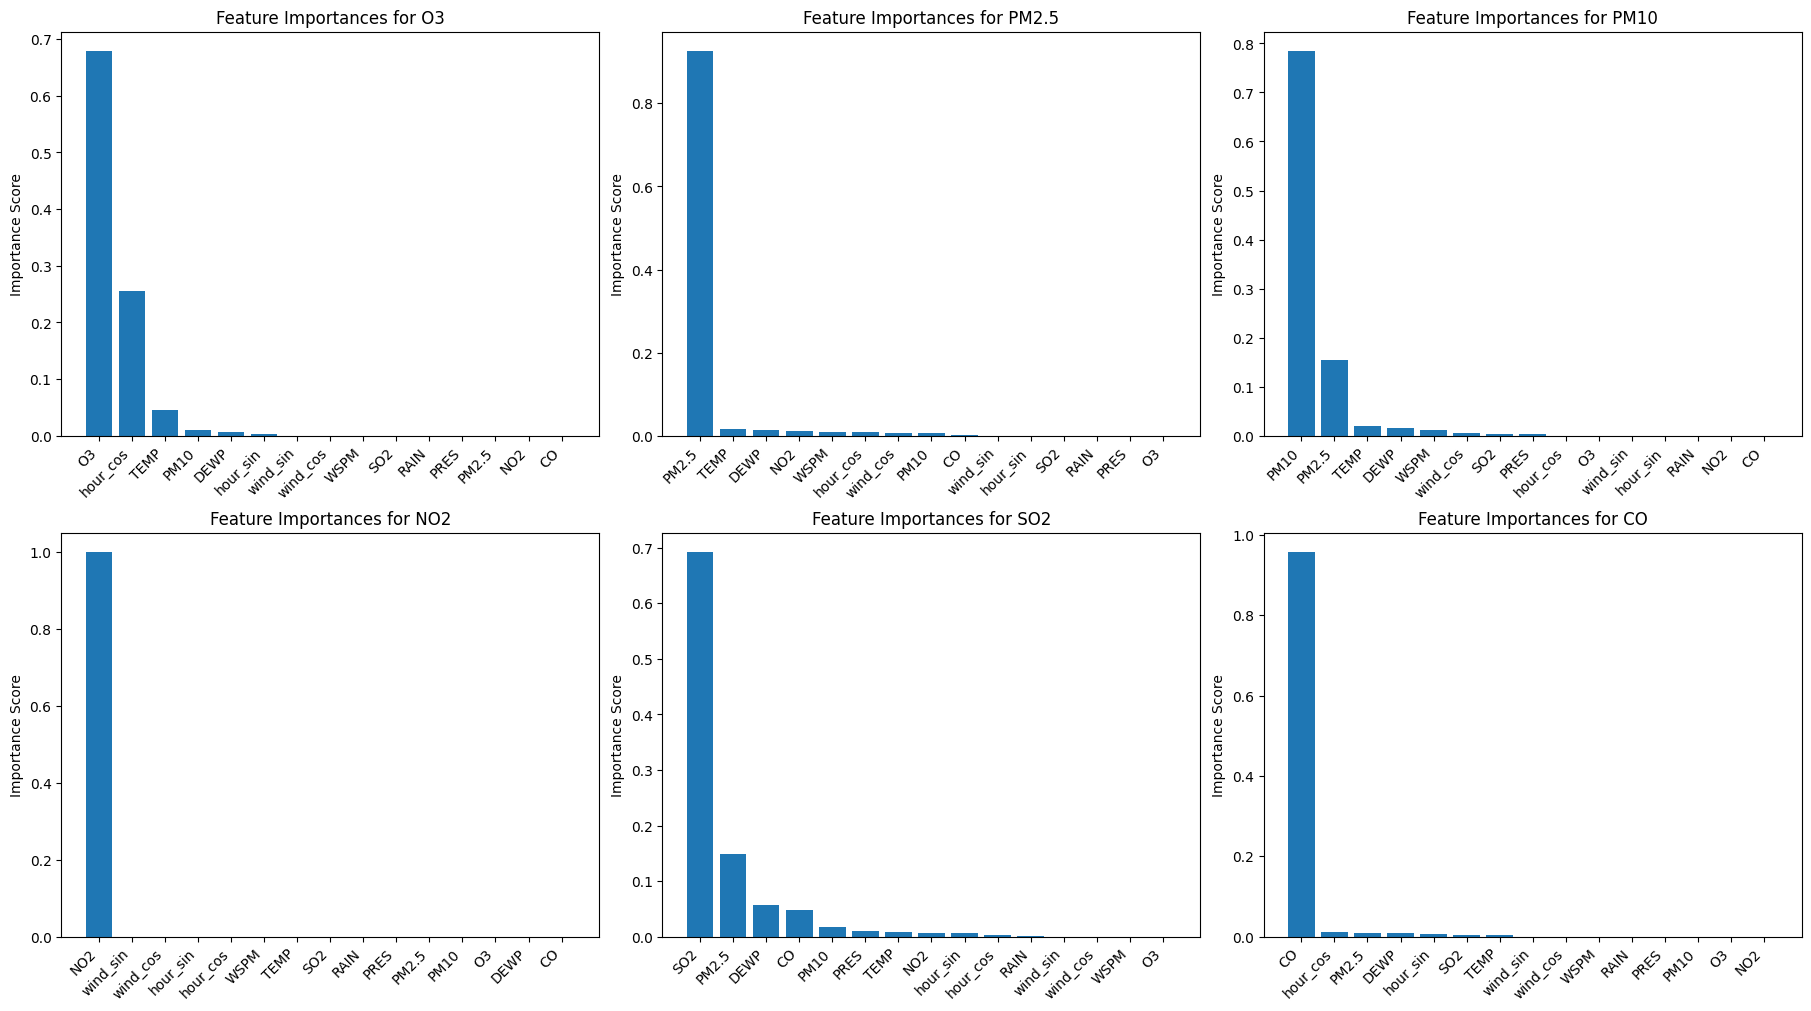

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
import math

# Modified feature_selection_for_pollutant to return top 3 features and importances for plotting
def feature_selection_for_pollutant(df_scaled, pollutant, threshold_norm, window, station_col='station', top_n=3):
    print(f"\nProcessing pollutant: {pollutant}")

    # Sort and compute moving average by station
    df_scaled = df_scaled.sort_values([station_col, 'timestamp'])
    df_scaled[f'{pollutant}_avg'] = df_scaled.groupby(station_col)[pollutant].transform(
        lambda x: x.rolling(window=window, min_periods=window).mean())

    # Create binary target for exceedances
    df_scaled[f'{pollutant}_exceed'] = (df_scaled[f'{pollutant}_avg'] > threshold_norm).astype(int)

    # Drop rows with NaN (from rolling average)
    df_clean = df_scaled.dropna(subset=[f'{pollutant}_avg']).reset_index(drop=True)

    # Feature set: exclude timestamp, station, moving avg, and target
    feature_cols = df_clean.columns.difference(['timestamp', station_col, f'{pollutant}_avg', f'{pollutant}_exceed'])
    X = df_clean[feature_cols]
    y = df_clean[f'{pollutant}_exceed']

    # If target is all zeros or ones (no exceedances), skip
    if y.nunique() < 2:
        print(f"⚠️  Skipping {pollutant} — insufficient exceedance variation in data.")
        return [], None, None

    # Train Decision Tree Classifier
    clf = DecisionTreeClassifier(criterion='gini', max_depth=5, random_state=42)
    clf.fit(X, y)

    # Get feature importances
    importances = clf.feature_importances_
    indices = np.argsort(importances)[::-1]

    # Select top N features for this pollutant
    top_features = [feature_cols[i] for i in indices[:top_n]]

    return top_features, importances, feature_cols

# List of all pollutants to process
pollutants = list(thresholds_cpcb.keys())
num_plots = len(pollutants)
cols = 3  # Number of columns in plot grid
rows = math.ceil(num_plots / cols)

# Create subplots grid
fig, axs = plt.subplots(rows, cols, figsize=(6 * cols, 5 * rows), constrained_layout=True)
axs = axs.flatten()  # Flatten in case of multiple rows

top_features_by_pollutant = {}

for i, pollutant in enumerate(pollutants):
    window = averaging_windows[pollutant]
    threshold_norm = normalized_thresholds[pollutant]
    top_features, importances, feature_cols = feature_selection_for_pollutant(
        preprocessed_df.copy(), pollutant, threshold_norm, window, top_n=3)

    if top_features and importances is not None:
        top_features_by_pollutant[pollutant] = top_features

        indices = np.argsort(importances)[::-1]
        axs[i].bar(range(len(importances)), importances[indices], align='center')
        axs[i].set_xticks(range(len(importances)))
        axs[i].set_xticklabels([feature_cols[j] for j in indices], rotation=45, ha='right')
        axs[i].set_ylabel("Importance Score")
        axs[i].set_title(f"Feature Importances for {pollutant}")
    else:
        axs[i].axis('off')  # Hide subplot if skipped

# Hide any unused subplots
for j in range(i + 1, len(axs)):
    fig.delaxes(axs[j])

plt.show()




In [ ]:
print("\nTop 3 features for each pollutant:")
for pollutant, features in top_features_by_pollutant.items():
    print(f"{pollutant}: {features}")

# Combine all top features across pollutants and remove duplicates
combined_top_features = list(set([feature for features in top_features_by_pollutant.values() for feature in features]))

print("\n✅ Combined input features for model training (duplicates removed):")
print(combined_top_features)


Top 3 features for each pollutant:
O3: ['O3', 'hour_cos', 'TEMP']
PM2.5: ['PM2.5', 'TEMP', 'DEWP']
PM10: ['PM10', 'PM2.5', 'TEMP']
NO2: ['NO2', 'wind_sin', 'wind_cos']
SO2: ['SO2', 'PM2.5', 'DEWP']
CO: ['CO', 'hour_cos', 'PM2.5']

✅ Combined input features for model training (duplicates removed):
['NO2', 'wind_sin', 'hour_cos', 'PM2.5', 'SO2', 'wind_cos', 'TEMP', 'CO', 'O3', 'PM10', 'DEWP']


 fits an ARIMA(1,1,1) model to each pollutant's time series in preprocessed_df

  computes the in-sample residuals by subtracting model predictions from actual values

   aligns these residuals with the original DataFrame's index

  fills any missing residual values using forward and backward fill methods.

In [ ]:
import pandas as pd
from statsmodels.tsa.arima.model import ARIMA

pollutants_to_predict = ['O3', 'PM2.5', 'PM10', 'NO2', 'SO2', 'CO']  # Output pollutants

# Assuming preprocessed_df has datetime index and pollutant columns
arima_order = (1, 1, 1)  # example order, tune per pollutant

# Store ARIMA residuals for each pollutant
arima_residuals = pd.DataFrame(index=preprocessed_df.index)

for pollutant in pollutants_to_predict:
    print(f"Fitting ARIMA for {pollutant}...")
    series = preprocessed_df[pollutant].dropna()

    # Fit ARIMA on full series or training part only (better)
    model_arima = ARIMA(series, order=arima_order)
    model_fit = model_arima.fit()

    # Predict in-sample to get residuals
    pred = model_fit.predict(start=series.index[0], end=series.index[-1])
    residual = series - pred

    # Align residuals with original dataframe index
    arima_residuals[pollutant] = residual.reindex(preprocessed_df.index)

# Fill any NaNs in residuals (e.g., forward fill)
arima_residuals.fillna(method='ffill', inplace=True)
arima_residuals.fillna(method='bfill', inplace=True)


Fitting ARIMA for O3...
Fitting ARIMA for PM2.5...
Fitting ARIMA for PM10...
Fitting ARIMA for NO2...
Fitting ARIMA for SO2...
Fitting ARIMA for CO...


<ipython-input-11-34ac4b72319f>:28: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  arima_residuals.fillna(method='ffill', inplace=True)
<ipython-input-11-34ac4b72319f>:29: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  arima_residuals.fillna(method='bfill', inplace=True)


In [ ]:
# Create new feature list including ARIMA residuals
residual_feature_names = [f'{pollutant}_arima_residual' for pollutant in pollutants_to_predict]

# Add residual columns to preprocessed_df
for col in residual_feature_names:
    preprocessed_df[col] = arima_residuals[col.replace('_arima_residual', '')]

# New combined features including residuals
combined_features_with_residuals = combined_top_features + residual_feature_names






Data Conversion:  build the 3D input array X with shape (samples, time_steps, features) and 2D target array y with shape (samples, targets).

Sanity Checks: After dataset creation, it asserts that there are no missing values (NaNs) in both input features and targets to ensure data integrity before training.

Feature Scaling: The input features are reshaped and scaled using StandardScaler to normalize the data, then reshaped back to 3D; targets are also scaled separately to improve model convergence.

Train-Test Split: The scaled dataset is split into training and testing subsets (80%-20%) for model training and evaluation.

In [ ]:
from sklearn.preprocessing import StandardScaler

time_steps=24

def create_lstm_dataset(df, feature_cols, target_cols, time_steps):
    X, y = [], []
    feature_array = df[feature_cols].to_numpy()
    target_array = df[target_cols].to_numpy()

    for i in range(len(df) - time_steps):
        X.append(feature_array[i:i+time_steps])
        y.append(target_array[i+time_steps])  # Predicting next time step
    return np.array(X), np.array(y)
X, y = create_lstm_dataset(preprocessed_df, combined_features_with_residuals, pollutants_to_predict, time_steps)

# Sanity checks and scaling as before
assert not np.isnan(X).any(), "Input features contain NaNs"
assert not np.isnan(y).any(), "Targets contain NaNs"

# Scale features including residuals
feature_scaler = StandardScaler()
X_reshaped = X.reshape(-1, len(combined_features_with_residuals))
X_scaled = feature_scaler.fit_transform(X_reshaped).reshape(X.shape)

target_scaler = StandardScaler()
y_scaled = target_scaler.fit_transform(y)

# Train/test split
train_size = int(0.8 * len(X_scaled))
X_train, X_test = X_scaled[:train_size], X_scaled[train_size:]
y_train, y_test = y_scaled[:train_size], y_scaled[train_size:]


4.MODEL TRAINING AND EVALUATION

Input(shape=(time_steps, len(combined_features_with_residuals)))

→ Conv1D(filters=32, kernel_size=3, activation='relu', padding='same')

→ MaxPooling1D(pool_size=2)

→ LSTM(64, return_sequences=False)

→ Dropout(0.3)

→ Dense(num_outputs, activation='linear')

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Conv1D, MaxPooling1D, LSTM, Dropout, Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
import tensorflow as tf

num_outputs = len(pollutants_to_predict)

model = Sequential([
    Input(shape=(time_steps, len(combined_features_with_residuals))),
    Conv1D(filters=32, kernel_size=3, activation='relu', padding='same'),
    MaxPooling1D(pool_size=2),
    LSTM(64, return_sequences=False),
    Dropout(0.3),
    Dense(num_outputs, activation='linear')
])

# ---- Custom metrics ----
def rmse(y_true, y_pred):
    return tf.sqrt(tf.reduce_mean(tf.square(y_true - y_pred)))


def r_squared(y_true, y_pred):
    SS_res = tf.reduce_sum(tf.square(y_true - y_pred))
    SS_tot = tf.reduce_sum(tf.square(y_true - tf.reduce_mean(y_true)))
    return 1 - SS_res / (SS_tot + tf.keras.backend.epsilon())

optimizer = Adam(learning_rate=0.0005, clipnorm=1.0)
model.compile(optimizer=optimizer, loss='mse', metrics=['mae', rmse, r_squared])

#  EarlyStopping → if validation loss doesn’t improve for 15 epochs, training stops → helps prevent overfitting.
early_stop = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True, verbose=1)

history = model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=64,
    validation_split=0.2,
    callbacks=[early_stop],
    shuffle=False,
    verbose=2
)

test_metrics = model.evaluate(X_test, y_test, verbose=0)
print(f"\nTest Performance:")
print(f"MSE: {test_metrics[0]:.4f}")
print(f"MAE: {test_metrics[1]:.4f}")
print(f"RMSE: {test_metrics[2]:.4f}")
print(f"R²: {test_metrics[3]:.4f}")


Epoch 1/100
4208/4208 - 75s - 18ms/step - loss: 0.1682 - mae: 0.2610 - r_squared: 0.7613 - rmse: 0.3699 - val_loss: 0.1214 - val_mae: 0.2251 - val_r_squared: 0.8191 - val_rmse: 0.3284
Epoch 2/100
4208/4208 - 69s - 16ms/step - loss: 0.1175 - mae: 0.2171 - r_squared: 0.8278 - rmse: 0.3169 - val_loss: 0.1065 - val_mae: 0.2040 - val_r_squared: 0.8414 - val_rmse: 0.3072
Epoch 3/100
4208/4208 - 98s - 23ms/step - loss: 0.1118 - mae: 0.2101 - r_squared: 0.8364 - rmse: 0.3089 - val_loss: 0.1010 - val_mae: 0.1948 - val_r_squared: 0.8513 - val_rmse: 0.2981
Epoch 4/100
4208/4208 - 66s - 16ms/step - loss: 0.1088 - mae: 0.2070 - r_squared: 0.8400 - rmse: 0.3051 - val_loss: 0.0951 - val_mae: 0.1881 - val_r_squared: 0.8581 - val_rmse: 0.2896
Epoch 5/100
4208/4208 - 52s - 12ms/step - loss: 0.1071 - mae: 0.2053 - r_squared: 0.8421 - rmse: 0.3029 - val_loss: 0.0933 - val_mae: 0.1843 - val_r_squared: 0.8633 - val_rmse: 0.2852
Epoch 6/100
4208/4208 - 82s - 19ms/step - loss: 0.1059 - mae: 0.2040 - r_squared

5.PLOTING METRICS FOR TRAIN AND TEST ACCORDING TO EPOCHS

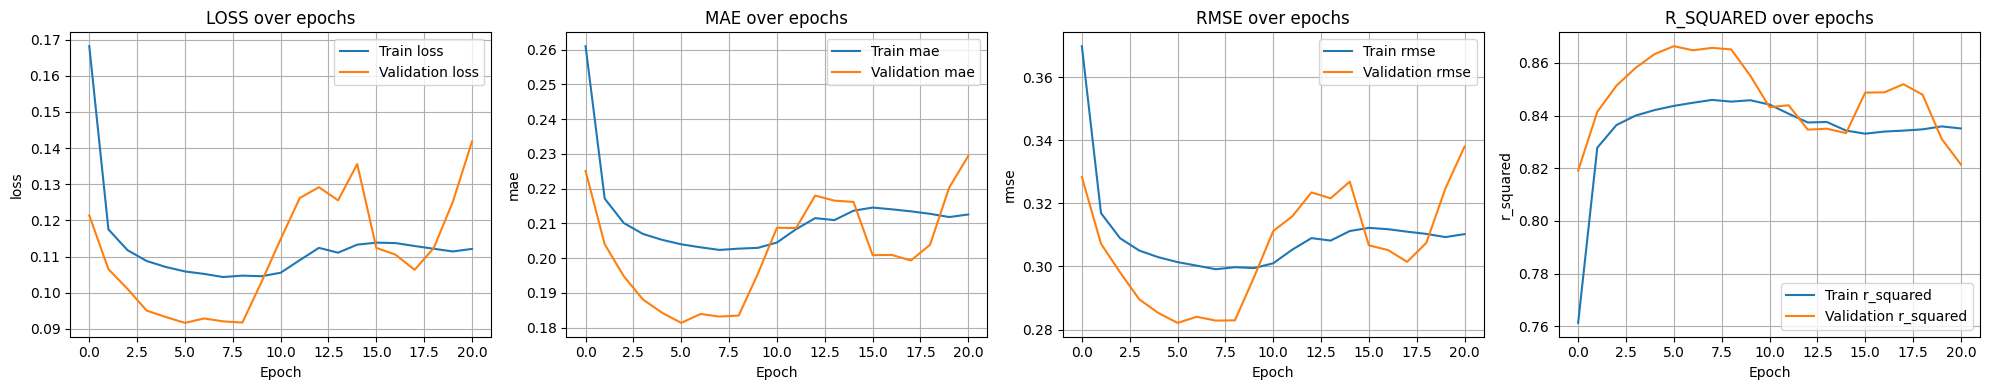

In [ ]:
import matplotlib.pyplot as plt

# Metrics tracked during training (keys in history.history)
metrics = ['loss', 'mae', 'rmse', 'r_squared']  # 'loss' corresponds to MSE in your model

num_metrics = len(metrics)

fig, axes = plt.subplots(1, num_metrics, figsize=(5 * num_metrics, 4), sharex=True)

for i, metric in enumerate(metrics):
    ax = axes[i]
    ax.plot(history.history[metric], label=f'Train {metric}')
    ax.plot(history.history[f'val_{metric}'], label=f'Validation {metric}')
    ax.set_title(f'{metric.upper()} over epochs')
    ax.set_xlabel('Epoch')
    ax.set_ylabel(metric)
    ax.legend()
    ax.grid(True)

plt.tight_layout()
plt.show()


6.PLOTTING PREDICTED AND ACTUAL CONCENTRATIONS OF EACH POLLUTANT AS PER TIME SERIES

2630/2630 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step


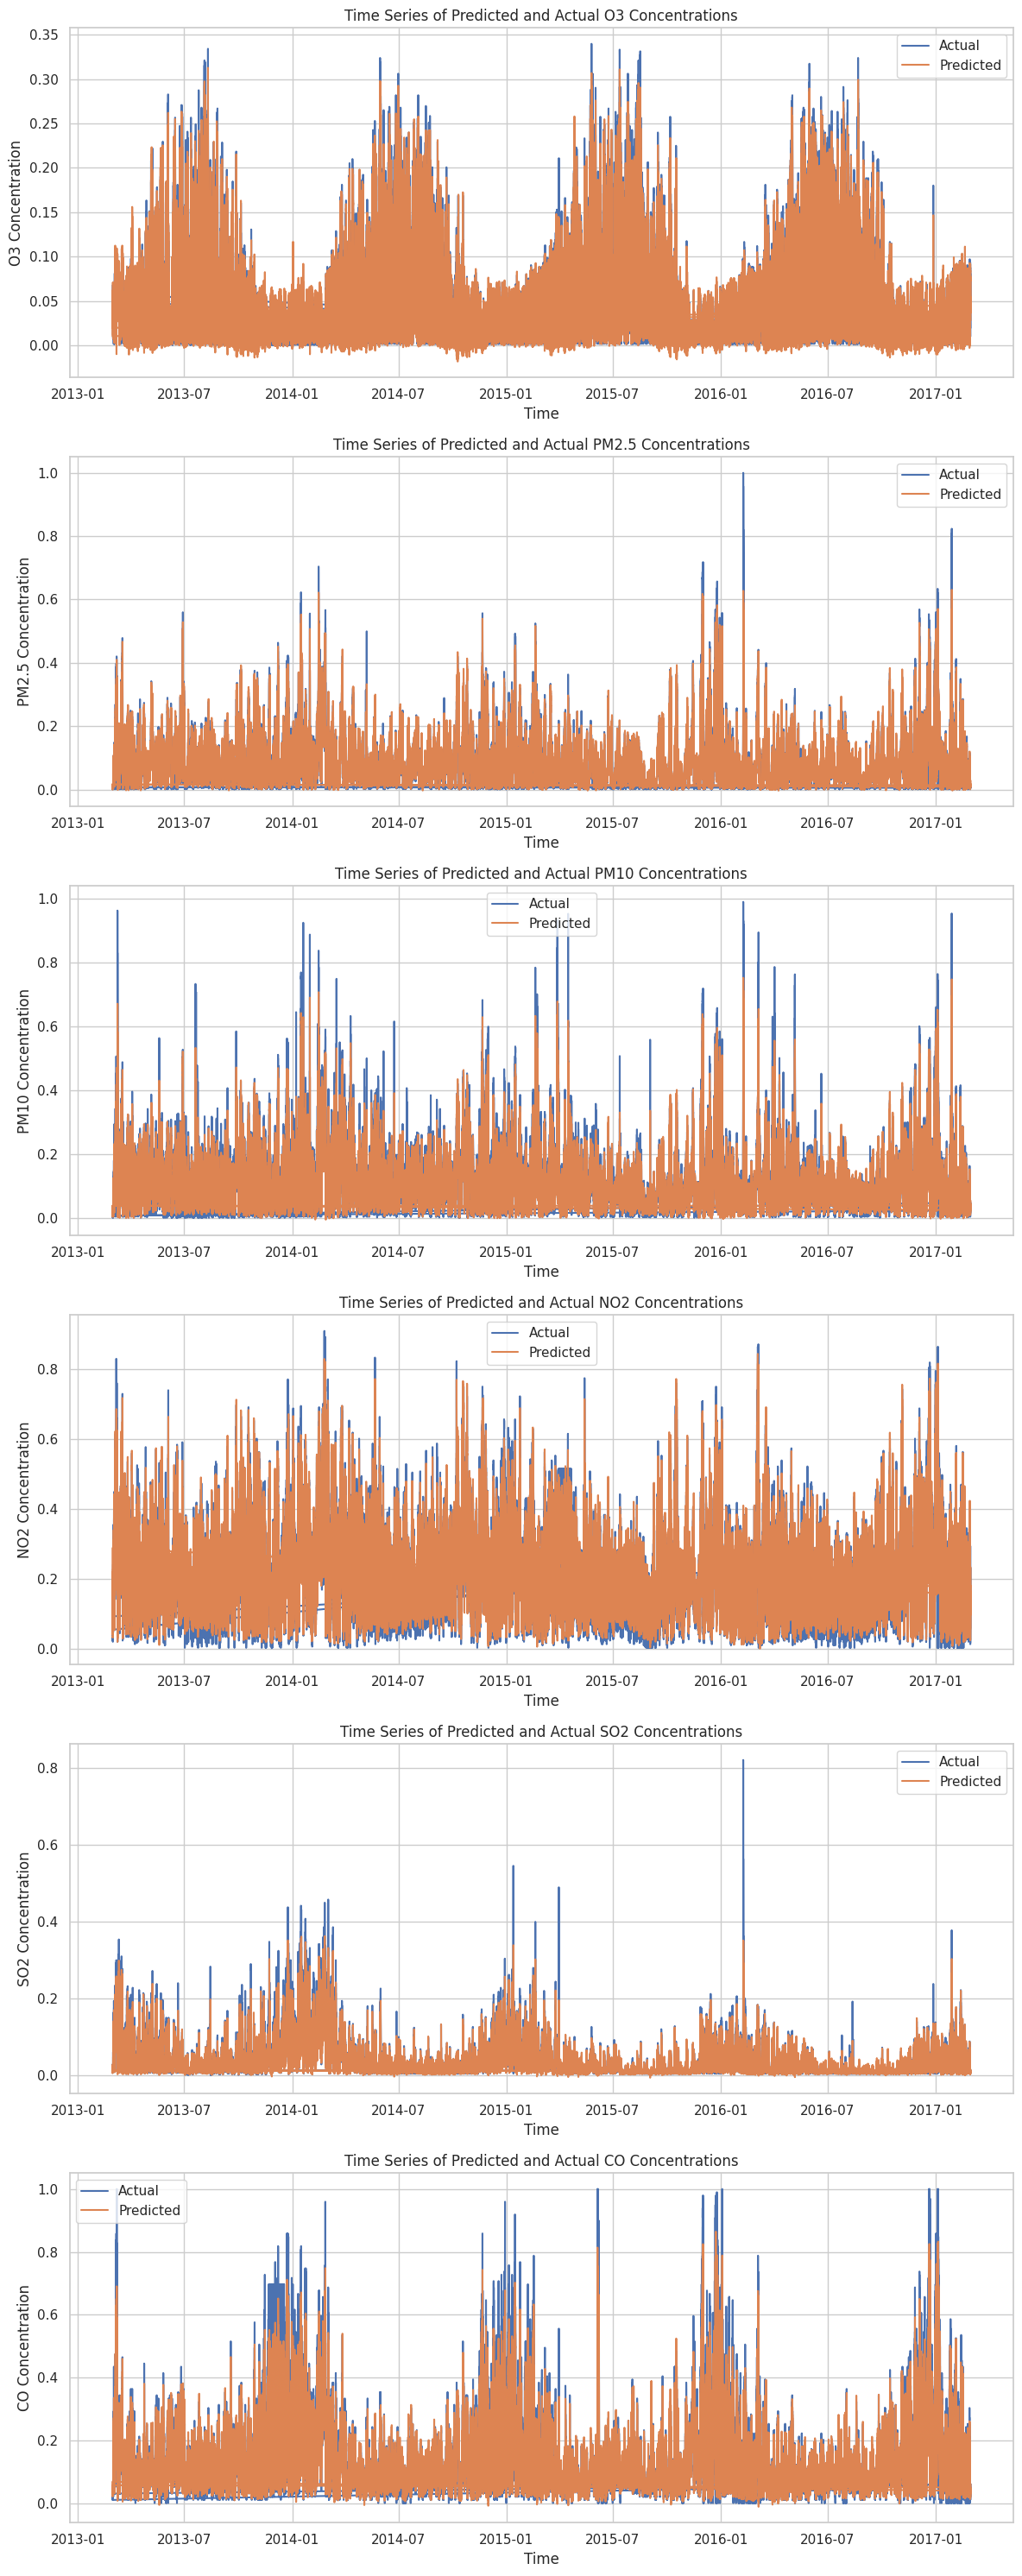

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Predict on test set (scaled)
y_pred_scaled = model.predict(X_test)

# Inverse transform to original scale
y_pred = target_scaler.inverse_transform(y_pred_scaled)
y_true = target_scaler.inverse_transform(y_test)

# Number of pollutants
num_pollutants = len(pollutants_to_predict)

# Set seaborn style
sns.set(style='whitegrid')


# 2. Time series plot: Predicted and Actual concentrations over time for each pollutant
# Assuming you have a datetime index for test samples (adjust accordingly)
# For example, if preprocessed_df has a 'timestamp' column, you can extract test timestamps:
# Total samples after sequence creation
total_samples = len(preprocessed_df) - time_steps

# Index where test samples start in the original dataframe (after sequences)
test_start_idx = int(0.8 * total_samples) + time_steps

# Slice timestamps to match test sample count
test_timestamps = preprocessed_df['timestamp'].iloc[test_start_idx : test_start_idx + len(y_true)].reset_index(drop=True)


plt.figure(figsize=(12, 5 * num_pollutants))
for i, pollutant in enumerate(pollutants_to_predict):
    plt.subplot(num_pollutants, 1, i+1)
    plt.plot(test_timestamps, y_true[:, i], label='Actual')
    plt.plot(test_timestamps, y_pred[:, i], label='Predicted')
    plt.title(f'Time Series of Predicted and Actual {pollutant} Concentrations')
    plt.xlabel('Time')
    plt.ylabel(f'{pollutant} Concentration')
    plt.legend()
plt.tight_layout()
plt.show()


7.PLOTTING AQI

In [ ]:
import pandas as pd

# Suppose y_pred is your model's predicted values (numpy array), shape (num_samples, num_pollutants)
# And you have a datetime index for test samples, e.g., test_timestamps (pandas Series or DatetimeIndex)


# Inverse scale predictions if needed
y_pred_original_scale = target_scaler.inverse_transform(y_pred_scaled)  # shape (num_samples, num_pollutants)

# Create DataFrame
predicted_pollutant_concentrations = pd.DataFrame(
    data=y_pred_original_scale,
    index=test_timestamps,
    columns=pollutants_to_predict
)


<ipython-input-33-9ff960fa0d41>:115: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  dates = pd.date_range(start='2025-06-01', periods=240, freq='H')


                             O3      PM2.5        PM10        NO2        SO2  \
2025-06-01 00:00:00   92.654956  57.136206  119.640115  69.966903  19.389465   
2025-06-01 01:00:00  101.874478  50.507248   97.108421  64.146839  47.276786   
2025-06-01 02:00:00   92.250926  23.492118   79.731484  35.733287  51.609769   
2025-06-01 03:00:00   57.124926  91.085732  100.910863  75.550257  74.232103   
2025-06-01 04:00:00  120.682973  60.073270  121.477245  60.631759  72.212800   

                              CO  
2025-06-01 00:00:00  2066.831710  
2025-06-01 01:00:00  1677.491492  
2025-06-01 02:00:00  1469.210918  
2025-06-01 03:00:00  1063.386257  
2025-06-01 04:00:00  1325.017276  


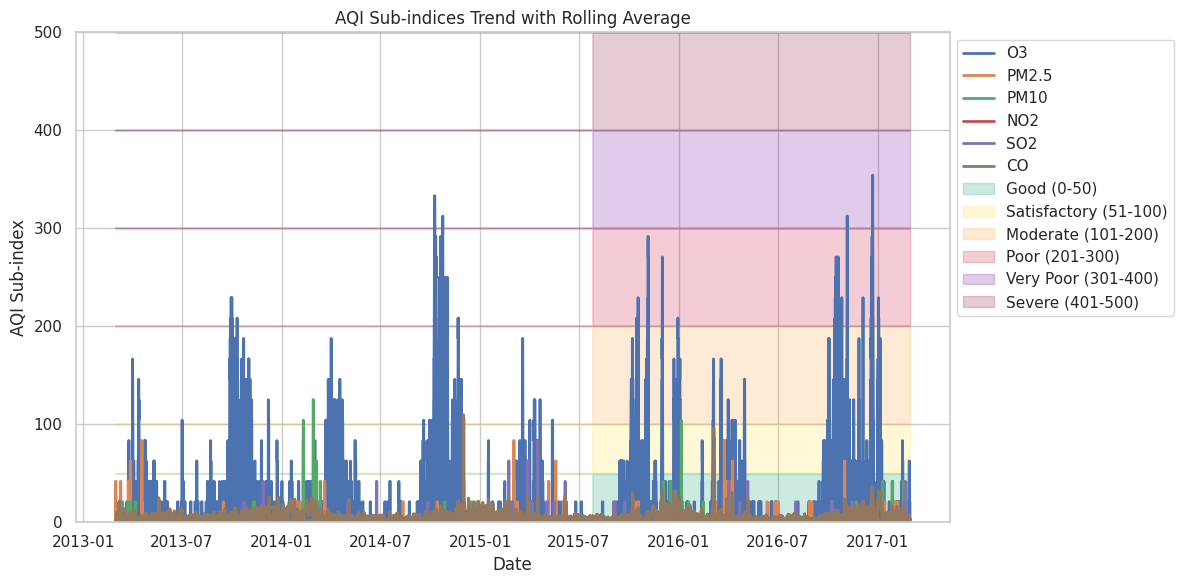

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# CPCB AQI breakpoints for each pollutant
breakpoints = {
    'O3': [
        (0, 50, 0, 50),                              #(CLow,CHigh,AQI_low,AQI_high)
        (51, 100, 51, 100),
        (101, 168, 101, 200),
        (169, 208, 201, 300),
        (209, 748, 301, 400),
        (749, 1000, 401, 500)
    ],
    'PM2.5': [
        (0, 30, 0, 50),
        (31, 60, 51, 100),
        (61, 90, 101, 200),
        (91, 120, 201, 300),
        (121, 250, 301, 400),
        (251, 350, 401, 500)
    ],
    'PM10': [
        (0, 50, 0, 50),
        (51, 100, 51, 100),
        (101, 250, 101, 200),
        (251, 350, 201, 300),
        (351, 430, 301, 400),
        (431, 600, 401, 500)
    ],
    'NO2': [
        (0, 40, 0, 50),
        (41, 80, 51, 100),
        (81, 180, 101, 200),
        (181, 280, 201, 300),
        (281, 400, 301, 400),
        (401, 1000, 401, 500)
    ],
    'SO2': [
        (0, 40, 0, 50),
        (41, 80, 51, 100),
        (81, 380, 101, 200),
        (381, 800, 201, 300),
        (801, 1600, 301, 400),
        (1601, 2620, 401, 500)
    ],
    'CO': [
        (0, 1, 0, 50),
        (1.1, 2, 51, 100),
        (2.1, 10, 101, 200),
        (10.1, 17, 201, 300),
        (17.1, 34, 301, 400),
        (34.1, 50, 401, 500)
    ]
}

def calculate_aqi_subindex(pollutant, concentration):
    if pollutant not in breakpoints:
        raise ValueError(f"Pollutant {pollutant} not supported for AQI calculation.")
    for Clow, Chigh, Ilow, Ihigh in breakpoints[pollutant]:
        if Clow <= concentration <= Chigh:
            aqi = ((Ihigh - Ilow) / (Chigh - Clow)) * (concentration - Clow) + Ilow
            return round(aqi, 2)
    return 500.0  # Above highest breakpoint

def calculate_overall_aqi(pollutant_concentrations):
    sub_indices = {}
    for pollutant, conc in pollutant_concentrations.items():
        sub_indices[pollutant] = calculate_aqi_subindex(pollutant, conc)
    overall_aqi = max(sub_indices.values())
    return sub_indices, overall_aqi

# Vectorized version for DataFrame of concentrations
def calculate_subindices_df(df):
    subindices = pd.DataFrame(index=df.index)
    for pollutant in df.columns:
        subindices[pollutant] = df[pollutant].apply(lambda x: calculate_aqi_subindex(pollutant, x))
    return subindices

# AQI categories and colors for plotting
aqi_categories = [
    (0, 50, 'Good', '#009866'),
    (51, 100, 'Satisfactory', '#ffde33'),
    (101, 200, 'Moderate', '#ff9933'),
    (201, 300, 'Poor', '#cc0033'),
    (301, 400, 'Very Poor', '#660099'),
    (401, 500, 'Severe', '#7e0023')
]

def plot_aqi_trends(dates, sub_indices_df, rolling_window=24):
    sub_indices_smooth = sub_indices_df.rolling(window=rolling_window, min_periods=1).mean()

    plt.figure(figsize=(12, 6))

    # Plot pollutant AQI sub-indices
    for pollutant in sub_indices_df.columns:
        plt.plot(dates, sub_indices_smooth[pollutant], label=pollutant, linewidth=2)

    ymin, ymax = 0, 500
    # Plot shaded AQI categories
    for low, high, category, color in aqi_categories:
        plt.fill_between(dates, low, high, color=color, alpha=0.2, label=f'{category} ({low}-{high})')

    plt.title('AQI Sub-indices Trend with Rolling Average')
    plt.xlabel('Date')
    plt.ylabel('AQI Sub-index')
    plt.ylim(ymin, ymax)
    plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
    plt.grid(True)
    plt.tight_layout()
    plt.show()


# Create hourly datetime index for 10 days (240 hours)
dates = pd.date_range(start='2025-06-01', periods=240, freq='H')

# Generate synthetic pollutant concentrations based on CPCB thresholds
example_concentrations = pd.DataFrame({
    'O3': np.clip(np.random.normal(90, 20, size=240), 0, 1000),
    'PM2.5': np.clip(np.random.normal(55, 15, size=240), 0, 350),
    'PM10': np.clip(np.random.normal(90, 25, size=240), 0, 600),
    'NO2': np.clip(np.random.normal(70, 20, size=240), 0, 1000),
    'SO2': np.clip(np.random.normal(60, 20, size=240), 0, 2620),
    'CO': np.clip(np.random.normal(1500, 400, size=240), 0, 5000),  # Extended upper bound for safety
}, index=dates)

print(example_concentrations.head())


# Calculate AQI sub-indices DataFrame
sub_indices_df = calculate_subindices_df(predicted_pollutant_concentrations)

# Plot AQI trends with rolling average smoothing
plot_aqi_trends(sub_indices_df.index, sub_indices_df, rolling_window=24)

